<a href="https://colab.research.google.com/github/hemalatha0601/predicting_solar_power/blob/main/solar_panal_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import joblib

In [ ]:
df=pd.read_csv("solar_power_output (1).csv")
df.head()
df.tail()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
495,18.833806,27.326566,701.391519,6.569552,352.480220
496,24.591403,93.385086,657.541311,9.566146,326.834297
497,11.943366,30.945490,517.144639,0.689580,259.133251
498,34.359870,96.018988,441.807202,0.570547,223.778239
499,34.655269,55.680462,877.000285,2.821871,435.410369


In [ ]:
x=df[['temperature','humidity','solar_irradiance','wind_speed']]
y=df['solar_power_output']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.6,random_state=50)
x_test

,temperature,humidity,solar_irradiance,wind_speed
331,28.946153,56.195161,747.281600,6.018816
374,11.779716,22.030908,322.507967,7.328015
434,12.102670,33.734343,225.686129,6.764679
354,11.764219,36.411171,538.002047,9.189265
345,25.396252,53.169930,482.944001,2.406927
...,...,...,...,...
389,30.170868,39.453775,508.410587,9.918100
352,26.467341,36.792447,494.753877,8.613700
327,25.293019,47.756256,810.728656,9.684888
74,27.671434,88.989097,988.950151,2.167398


In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_test)
y_pred

array([374.65070331, 162.45962386, 113.53952995, 269.71137913,
       242.18042861,  93.11054841, 310.57144014, 204.44260635,
       359.78158923, 229.14550571, 485.86756279, 481.9670749 ,
        82.56563426, 302.78129594, 245.54269624, 370.03726005,
       124.15071891, 401.25311112, 215.77443528, 472.08119916,
       172.98947287, 411.45531847, 193.8528189 , 125.73935918,
       498.34246145, 100.55957117, 272.59176932, 134.99078499,
       473.85505868,  63.67869523, 197.840599  , 328.27415085,
       327.82720588, 440.95192297, 161.32906509, 328.3831483 ,
       345.1680965 , 443.7483464 ,  84.74992094, 403.33791353,
       451.91795154, 363.15739207, 441.94361835,  76.45895509,
       294.84391482, 344.22767422, 254.37242194, 496.03605769,
       274.16071733,  96.44184094, 488.53469788, 423.9244956 ,
       417.39245402, 352.26754145, 335.93940094, 291.0681925 ,
        57.56455318, 407.84594366, 214.69942055, 354.07262426,
       447.63603371, 474.10908506, 241.18063571, 442.68

In [ ]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"mean squared error:{mse}")
print(f"r-squarred:{r2}")

mean squared error:25.297589262837338
r-squarred:0.9985831298513728


In [ ]:
joblib.dump(model,'solar_power_prediction_model.pkl')

['solar_power_prediction_model.pkl']

In [ ]:
model=joblib.load("solar_power_prediction_model.pkl")
new_data=np.array([[19.36,75.85,266.61,5.19]] )
predicted_output=model.predict(new_data)
print(f"predicted solar power output:{predicted_output[0]}watts")

predicted solar power output:132.6913437555213watts


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


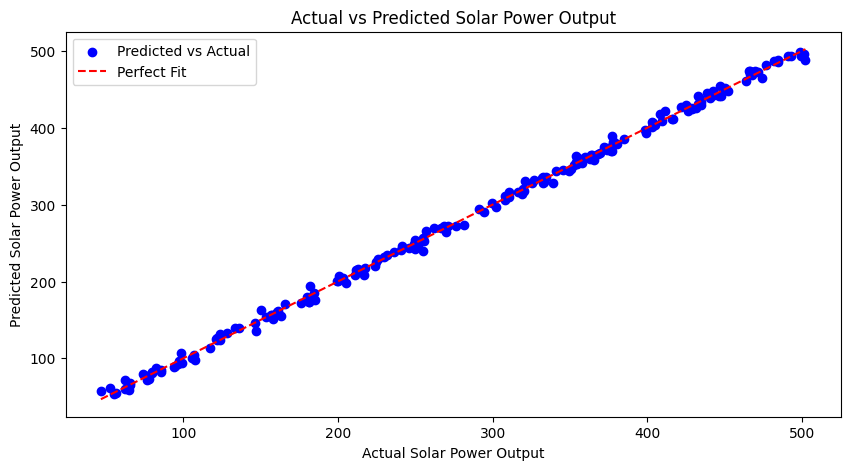

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression # Added
import joblib

# Re-defining necessary variables from previous steps
# Load the dataset
df = pd.read_csv("solar_power_output (1).csv")

# Define features (x) and target (y)
x = df[['temperature', 'humidity', 'solar_irradiance', 'wind_speed']]
y = df['solar_power_output']

# Perform train-test split to get y_test
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.6, random_state=50)

# Train the model (instead of loading to resolve FileNotFoundError)
model = LinearRegression() # Initialise the model
model.fit(x_train, y_train) # Train the model

# Predict with the trained model to get y_pred
y_pred = model.predict(x_test)

# Scatter plot to compare actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
# Diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel("Actual Solar Power Output")
plt.ylabel("Predicted Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output")
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

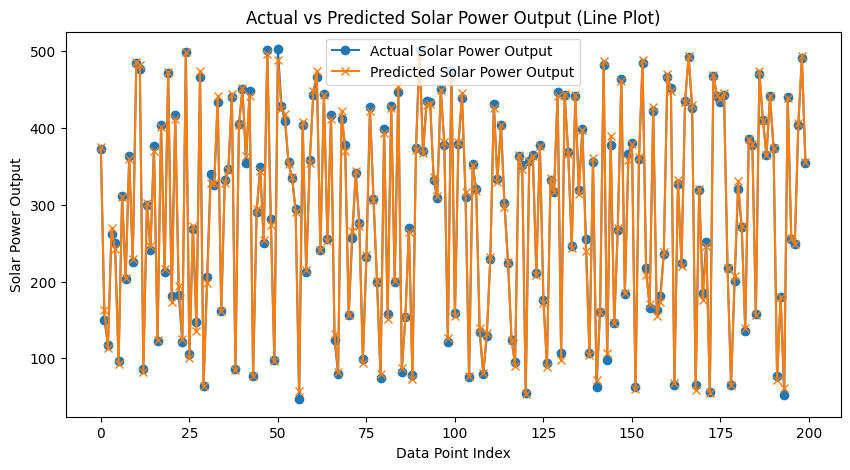

In [ ]:
# Line plot to show predictions and actual values
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test, label="Actual Solar Power Output", marker='o')
plt.plot(range(len(y_test)), y_pred, label="Predicted Solar Power Output", marker='x')
plt.xlabel("Data Point Index")
plt.ylabel("Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output (Line Plot)")
plt.legend()
plt.show()